In [7]:
from data_loader import load_data
import matplotlib.pyplot as plt
import pandas as pd

# Cargar datos para clasificación
data = load_data(task="classification")

print("Datos cargados correctamente")
print("X_train:", data.X_train.shape)
print("X_test:", data.X_test.shape)
print("y_train:", data.y_train.shape)
print("y_test:", data.y_test.shape)

Datos cargados correctamente
X_train: (100226, 28)
X_test: (610, 28)
y_train: (100226,)
y_test: (610,)


In [6]:
data.X_train.isna().sum()

user_avg             0
user_count           0
movie_avg            0
movie_count          0
interaction          0
abs_diff             0
user_sim_score       0
nmf_score            0
year                 0
genre_Action         0
genre_Adventure      0
genre_Animation      0
genre_Children       0
genre_Comedy         0
genre_Crime          0
genre_Documentary    0
genre_Drama          0
genre_Fantasy        0
genre_Film-Noir      0
genre_Horror         0
genre_IMAX           0
genre_Musical        0
genre_Mystery        0
genre_Romance        0
genre_Sci-Fi         0
genre_Thriller       0
genre_War            0
genre_Western        0
dtype: int64

In [6]:
data.X_train.head()

,user_avg,user_count,movie_avg,movie_count,interaction,abs_diff,user_sim_score,nmf_score,year,genre_Action,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,4.367965,231,3.250000,8,14.195887,1.117965,3.500479,0.198842,1996.0,0,...,0,0,0,0,0,1,0,0,0,0
1,4.367965,231,4.137755,196,18.073571,0.230210,3.741988,5.145786,1983.0,1,...,0,0,0,0,0,0,1,0,0,0
2,4.367965,231,3.361111,36,14.681217,1.006854,3.000000,1.175872,1942.0,0,...,0,0,0,0,0,0,0,0,0,0
3,4.367965,231,3.086957,138,13.483719,1.281009,3.273420,2.792576,1999.0,1,...,0,0,0,0,0,0,1,0,0,0
4,4.367965,231,2.903846,26,12.683899,1.464119,3.500479,0.314547,1999.0,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import pandas as pd

# Unimos y_train e y_test para ver también el total
y_all = pd.concat([data.y_train, data.y_test], axis=0)

class_summary = pd.DataFrame({
    "Train count": data.y_train.value_counts().sort_index(),
    "Train %": (data.y_train.value_counts(normalize=True).sort_index() * 100),
    "Test count": data.y_test.value_counts().sort_index(),
    "Test %": (data.y_test.value_counts(normalize=True).sort_index() * 100),
    "Total count": y_all.value_counts().sort_index(),
    "Total %": (y_all.value_counts(normalize=True).sort_index() * 100),
})

class_summary.index = ["Not liked", "Liked"]

# Redondear porcentajes
class_summary[["Train %", "Test %", "Total %"]] = class_summary[
    ["Train %", "Test %", "Total %"]
].round(2)

class_summary

,Train count,Train %,Test count,Test %,Total count,Total %
Not liked,52009,51.89,247,40.49,52256,51.82
Liked,48217,48.11,363,59.51,48580,48.18


Not liked    51.82
Liked        48.18
Name: proportion, dtype: float64

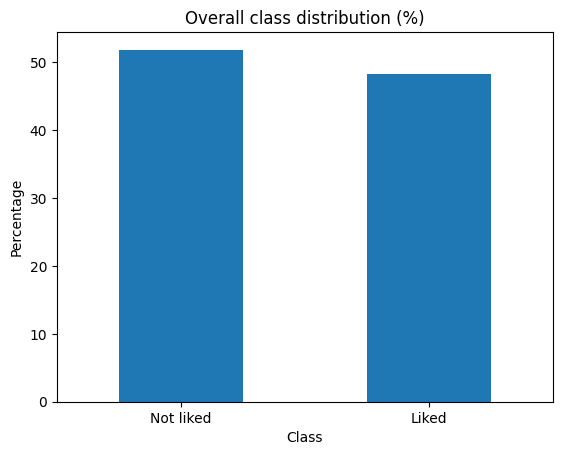

In [ ]:
y_all = pd.concat([data.y_train, data.y_test], axis=0)

class_percentages = (
    y_all.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

class_percentages.index = ["Not liked", "Liked"]

display(class_percentages)

class_percentages.plot(kind="bar")

plt.title("Overall class distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from data_loader import load_data
from models import build_models

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# =========================
# 1. Load classification data
# =========================
# data = load_data(task="classification")

X_train = data.X_train.copy()
X_test = data.X_test.copy()
y_train = data.y_train.copy()
y_test = data.y_test.copy()

# =========================
# 2. Remove nmf_score
# =========================
X_train_no_nmf = X_train.drop(columns=["nmf_score", "interaction"])
X_test_no_nmf = X_test.drop(columns=["nmf_score", "interaction" ])

# print("Original number of features:", X_train.shape[1])
# print("Number of features without nmf_score:", X_train_no_nmf.shape[1])

# =========================
# 3. Build only Logistic Regression model
# =========================
models = build_models(task="classification")
log_reg = models["LogisticRegression"]

# =========================
# 4. Train model
# =========================
log_reg.fit(X_train_no_nmf, y_train)

# =========================
# 5. Predictions
# =========================
y_pred = log_reg.predict(X_test_no_nmf)
y_proba = log_reg.predict_proba(X_test_no_nmf)[:, 1]

# =========================
# 6. Evaluation
# =========================
results = pd.DataFrame([{
    "Model": "LogisticRegression without nmf_score",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba)
}])
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# =========================
# 7. Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
print(cm)
results

[[154  93]
 [ 97 266]]


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression without nmf_score,0.688525,0.740947,0.732782,0.736842,0.728868


In [35]:
feature_names = X_train_no_nmf.columns

# Extract coefficients from the Logistic Regression pipeline
log_reg_model = log_reg.named_steps["model"]
log_reg_coef = log_reg_model.coef_[0]

log_reg_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_reg_coef,
    "Abs coefficient": abs(log_reg_coef)
}).sort_values("Abs coefficient", ascending=False)

log_reg_importance.head(20)

,Feature,Coefficient,Abs coefficient
2,movie_avg,1.173349,1.173349
0,user_avg,0.882850,0.882850
4,abs_diff,0.123963,0.123963
6,year,-0.036835,0.036835
3,movie_count,-0.030867,0.030867
5,user_sim_score,0.024373,0.024373
18,genre_IMAX,-0.022909,0.022909
11,genre_Comedy,0.022877,0.022877
7,genre_Action,-0.020093,0.020093
15,genre_Fantasy,-0.015581,0.015581


In [36]:
# =========================
# GradientBoosting without nmf_score
# =========================

gradient_boosting = models["GradientBoosting"]

gradient_boosting.fit(X_train_no_nmf, y_train)

y_pred_gb = gradient_boosting.predict(X_test_no_nmf)
y_proba_gb = gradient_boosting.predict_proba(X_test_no_nmf)[:, 1]

results_gb = pd.DataFrame([{
    "Model": "GradientBoosting without nmf_score",
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_gb, zero_division=0),
    "F1": f1_score(y_test, y_pred_gb, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba_gb)
}])

results_gb

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,GradientBoosting without nmf_score,0.680328,0.744186,0.705234,0.724187,0.720687


In [37]:
feature_names = X_train_no_nmf.columns
# Extract feature importance from the GradientBoosting pipeline
gb_model = gradient_boosting.named_steps["model"]
gb_importances = gb_model.feature_importances_

gb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_importances
}).sort_values("Importance", ascending=False)

gb_importance.head(20)

,Feature,Importance
2,movie_avg,0.606714
0,user_avg,0.355783
3,movie_count,0.019321
1,user_count,0.009017
5,user_sim_score,0.006315
6,year,0.002586
4,abs_diff,0.000264
7,genre_Action,0.000000
8,genre_Adventure,0.000000
9,genre_Animation,0.000000


In [39]:
# =========================
# MLP without nmf_score
# =========================

mlp = models["MLP"]

mlp.fit(X_train_no_nmf, y_train)

y_pred_mlp = mlp.predict(X_test_no_nmf)
y_proba_mlp = mlp.predict_proba(X_test_no_nmf)[:, 1]

results_mlp = pd.DataFrame([{
    "Model": "MLP without nmf_score",
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "Precision": precision_score(y_test, y_pred_mlp, zero_division=0),
    "Recall": recall_score(y_test, y_pred_mlp, zero_division=0),
    "F1": f1_score(y_test, y_pred_mlp, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, y_proba_mlp)
}])

results_mlp
cm = confusion_matrix(y_test, y_pred)
print(cm)
results

[[154  93]
 [ 97 266]]


,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,LogisticRegression without nmf_score,0.688525,0.740947,0.732782,0.736842,0.728868
